In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

print('All imports OK')

All imports OK


In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold      import TSNE
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score, davies_bouldin_score

In [3]:
cancer_df = pd.read_csv(r'C:\Users\parth\Desktop\week-3\cancer\survey-lung-cancer.csv')
cancer_df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    str  
dtypes

In [5]:
cancer_df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [6]:
cancer_df.duplicated().sum()

np.int64(33)

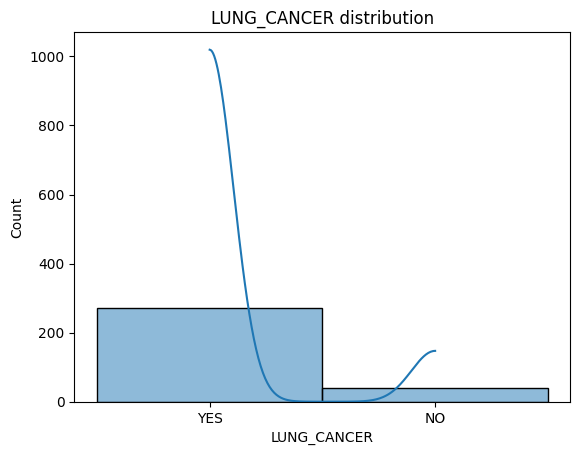

In [7]:
sns.histplot(cancer_df['LUNG_CANCER'],kde=True)
plt.title('LUNG_CANCER distribution')
plt.show()

In [8]:
cancer_df['LUNG_CANCER'] = cancer_df['LUNG_CANCER'].replace({'NO': 0, 'YES': 1}).astype(int)

In [9]:
cancer_df = cancer_df.drop(columns=['GENDER'])
X = cancer_df.drop(columns=['LUNG_CANCER'])
y = cancer_df['LUNG_CANCER']

In [10]:
cancer_df.drop_duplicates(inplace=True)

In [11]:
cancer_df.duplicated().sum()

np.int64(0)

In [12]:
cancer_df.info()

<class 'pandas.DataFrame'>
Index: 274 entries, 0 to 283
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   AGE                    274 non-null    int64
 1   SMOKING                274 non-null    int64
 2   YELLOW_FINGERS         274 non-null    int64
 3   ANXIETY                274 non-null    int64
 4   PEER_PRESSURE          274 non-null    int64
 5   CHRONIC DISEASE        274 non-null    int64
 6   FATIGUE                274 non-null    int64
 7   ALLERGY                274 non-null    int64
 8   WHEEZING               274 non-null    int64
 9   ALCOHOL CONSUMING      274 non-null    int64
 10  COUGHING               274 non-null    int64
 11  SHORTNESS OF BREATH    274 non-null    int64
 12  SWALLOWING DIFFICULTY  274 non-null    int64
 13  CHEST PAIN             274 non-null    int64
 14  LUNG_CANCER            274 non-null    int64
dtypes: int64(15)
memory usage: 34.2 KB


In [13]:
cancer_df.shape

(274, 15)

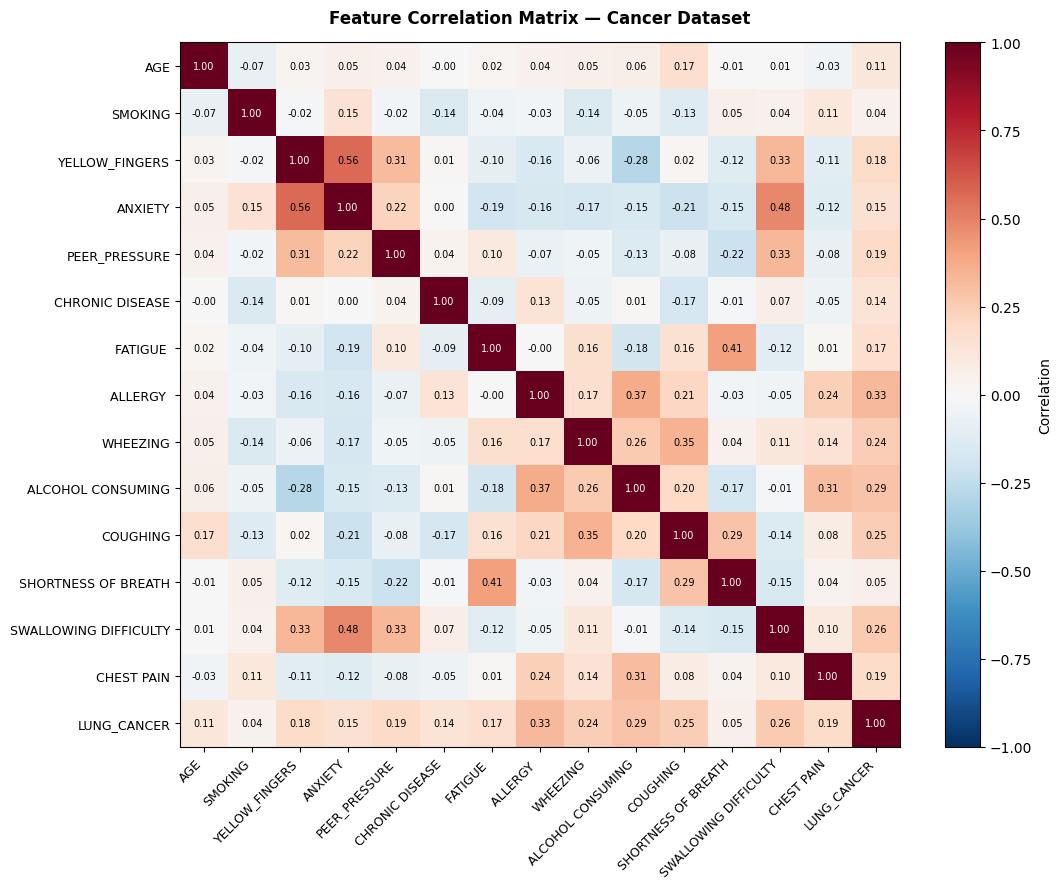

In [14]:
corr = cancer_df.select_dtypes(include=[np.number]).corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

# Annotate each cell
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')

ax.set_title('Feature Correlation Matrix — Cancer Dataset', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
pca_full = PCA(random_state=40)
pca_full.fit(X_scaled)
evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)
print("Explain Variance Ratio:", evr)
print("Cumulative Explain Variance Ratio:", cumulative_evr)
for i, (evr_i, cum_evr_i) in enumerate(zip(evr, cumulative_evr), 1):
    bar ='|' * int(evr_i * 100)  # Scale the bar length for better visualization
    print(f" pc {i:2d}: {evr_i:.3f} ({evr_i * 100:.1f}%), Cumulative EVR={cum_evr_i:.3f} {bar}")
print()
print('component needs for 80% variance:', np.argmax(cumulative_evr >= 0.80) + 1)
print('component needs for 90% variance:', np.argmax(cumulative_evr >= 0.90) + 1)
print('component needs for 95% variance:', np.argmax(cumulative_evr >= 0.95) + 1)
    

Explain Variance Ratio: [0.19061209 0.12877915 0.10959064 0.09098636 0.07815302 0.06879034
 0.06360504 0.05584264 0.05047666 0.04429085 0.04094857 0.03354483
 0.02372097 0.02065884]
Cumulative Explain Variance Ratio: [0.19061209 0.31939124 0.42898189 0.51996824 0.59812126 0.6669116
 0.73051664 0.78635929 0.83683595 0.88112679 0.92207536 0.95562019
 0.97934116 1.        ]
 pc  1: 0.191 (19.1%), Cumulative EVR=0.191 |||||||||||||||||||
 pc  2: 0.129 (12.9%), Cumulative EVR=0.319 ||||||||||||
 pc  3: 0.110 (11.0%), Cumulative EVR=0.429 ||||||||||
 pc  4: 0.091 (9.1%), Cumulative EVR=0.520 |||||||||
 pc  5: 0.078 (7.8%), Cumulative EVR=0.598 |||||||
 pc  6: 0.069 (6.9%), Cumulative EVR=0.667 ||||||
 pc  7: 0.064 (6.4%), Cumulative EVR=0.731 ||||||
 pc  8: 0.056 (5.6%), Cumulative EVR=0.786 |||||
 pc  9: 0.050 (5.0%), Cumulative EVR=0.837 |||||
 pc 10: 0.044 (4.4%), Cumulative EVR=0.881 ||||
 pc 11: 0.041 (4.1%), Cumulative EVR=0.922 ||||
 pc 12: 0.034 (3.4%), Cumulative EVR=0.956 |||
 pc 1

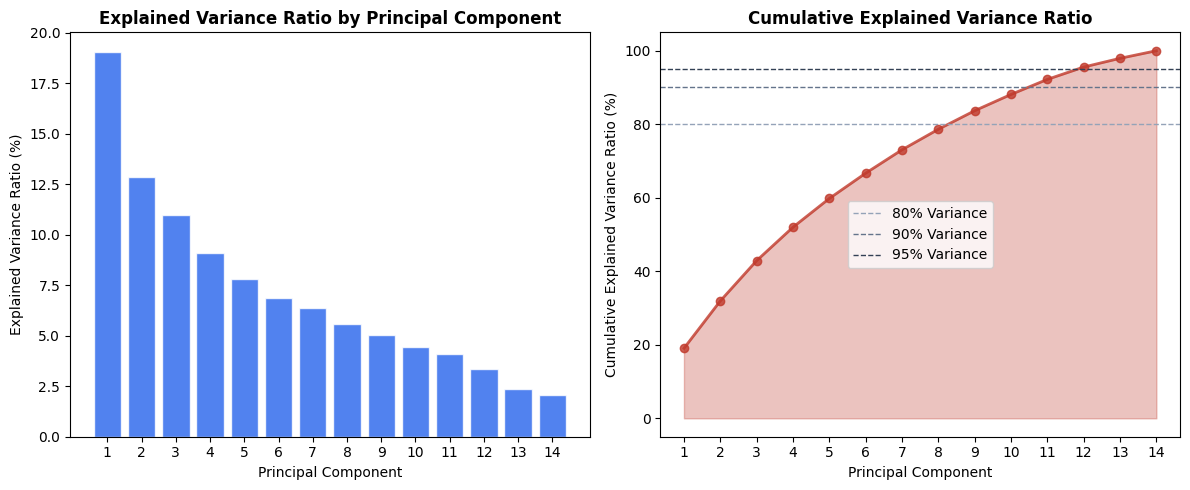

In [17]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
#scree plot
components = range(1, len(evr) + 1)
ax1.bar(components, evr *100, color='#2563EB', alpha=0.8, edgecolor='white')
ax1.set_xlabel('Principal Component', fontsize=10)
ax1.set_ylabel('Explained Variance Ratio (%)', fontsize=10)
ax1.set_title('Explained Variance Ratio by Principal Component', fontsize=12, fontweight='bold')
ax1.set_xticks(components)
#cumulative scree plot
ax2.plot(components, cumulative_evr * 100, marker='o', color='#c0392b', alpha=0.8, lw =2)
ax2.axhline(80, color='#94a3b8',ls='--', lw=1, label='80% Variance')
ax2.axhline(90, color='#64748b',ls='--', lw=1, label='90% Variance')
ax2.axhline(95, color='#334155',ls='--', lw=1, label='95% Variance')
ax2.fill_between(components, cumulative_evr * 100, color='#c0392b', alpha=0.3)
ax2.set_xlabel('Principal Component', fontsize=10)
ax2.set_ylabel('Cumulative Explained Variance Ratio (%)', fontsize=10)
ax2.set_title('Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
ax2.set_xticks(components)
ax2.legend()
plt.tight_layout()
plt.show()

Original shape: (309, 14)
Reduced shape: (309, 2)
Variance explained by 2 components: 31.9%


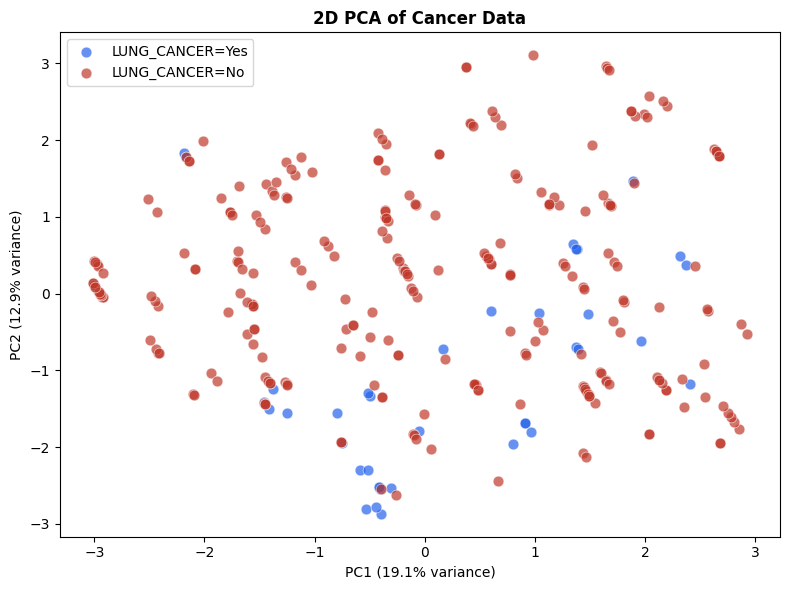

In [20]:
pca2d = PCA(n_components=2, random_state=40)
X_pca2d = pca2d.fit_transform(X_scaled)
print(f'Original shape: {X_scaled.shape}')
print(f'Reduced shape: {X_pca2d.shape}')
print(f'Variance explained by 2 components: {pca2d.explained_variance_ratio_.sum():.1%}')

colors = ['#2563eb', '#c0392b']
fig, ax = plt.subplots(figsize=(8, 6))
for cls, label, c in zip([0,1],['Yes', 'No'], colors):
    idx = y == cls
    ax.scatter(X_pca2d[idx, 0], X_pca2d[idx, 1], label=f'LUNG_CANCER={label}', alpha=0.7,s=60, edgecolor='white', lw=0.5, c=c)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax.set_title('2D PCA of Cancer Data', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Original shape: (309, 14)
Reduced shape: (309, 3)
Variance explained by 3 components: 42.9%


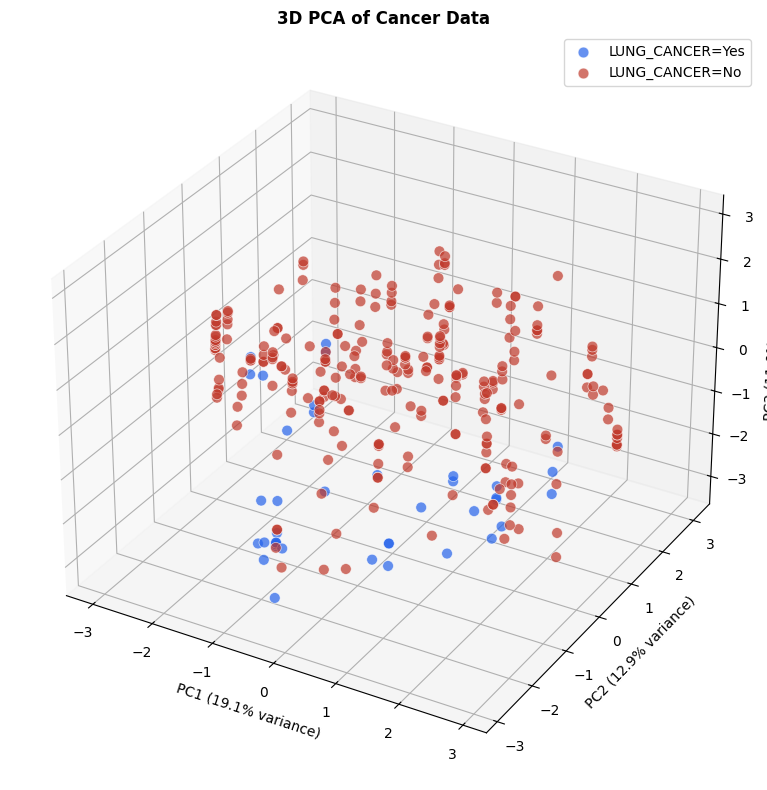

In [21]:
pca3d = PCA(n_components=3, random_state=40)
X_pca3d = pca3d.fit_transform(X_scaled)
print(f'Original shape: {X_scaled.shape}')
print(f'Reduced shape: {X_pca3d.shape}')
print(f'Variance explained by 3 components: {pca3d.explained_variance_ratio_.sum():.1%}')

colors = ['#2563eb', '#c0392b']
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for cls, label, c in zip([0,1],['Yes', 'No'], colors):
    idx = y == cls
    ax.scatter(X_pca3d[idx, 0], X_pca3d[idx, 1], X_pca3d[idx, 2], label=f'LUNG_CANCER={label}', alpha=0.7,s=60, edgecolor='white', lw=0.5, c=c)
ax.set_xlabel(f'PC1 ({pca3d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca3d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax.set_zlabel(f'PC3 ({pca3d.explained_variance_ratio_[2]:.1%} variance)', fontsize=10)
ax.set_title('3D PCA of Cancer Data', fontsize=12, fontweight='bold')
ax.legend() 
plt.tight_layout()
plt.show()

In [26]:
cum_evr = np.cumsum(evr)
n_components_95 = np.argmax(cum_evr >= 0.95) + 1
print(f'Number of principal components needed to retain 95% variance: {n_components_95}')

Number of principal components needed to retain 95% variance: 12


PCA Loadings for 2D PCA
                         PC1    PC2
ANXIETY                0.457  0.107
YELLOW_FINGERS         0.407  0.040
SWALLOWING DIFFICULTY  0.346  0.286
PEER_PRESSURE          0.309  0.069
COUGHING              -0.307  0.025
ALCOHOL CONSUMING     -0.273  0.508
WHEEZING              -0.252  0.217
ALLERGY               -0.245  0.344
SHORTNESS OF BREATH   -0.209 -0.429
CHEST PAIN            -0.185  0.330
FATIGUE               -0.171 -0.403
CHRONIC DISEASE        0.069  0.120
SMOKING                0.068 -0.040
AGE                   -0.035  0.076


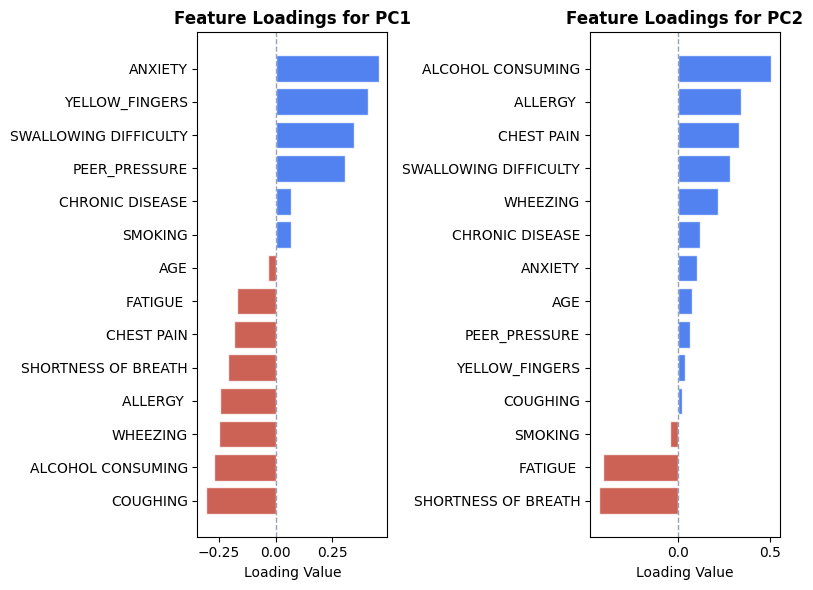

In [40]:
#loadings = pd.DataFrame(
#    pca_full.components_.T[:, :n_components_95],
#    columns=[f'PC{i+1}' for i in range(n_components_95)],
#    index=X.columns
#).round(3)
#print(loadings)

loadings = pd.DataFrame(
    pca2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
).round(3)
print('PCA Loadings for 2D PCA')
print(loadings.sort_values('PC1',key=abs, ascending=False))
fig, axes = plt.subplots(1,2,figsize=(8, 6))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    sorted_df = loadings[pc].sort_values()
    colors = ['#c0392b' if val < 0 else '#2563eb' for val in sorted_df]
    ax.barh(sorted_df.index, sorted_df.values, color=colors, alpha=0.8, edgecolor='white')
    ax.set_title(f'Feature Loadings for {pc}', fontsize=12, fontweight='bold')
    ax.axvline(0, color='#94a3b8', ls='--', lw=1)
    ax.set_xlabel('Loading Value', fontsize=10)
plt.tight_layout()
plt.show()

PCA Loadings for 3D PCA
                         PC1    PC2    PC3
ANXIETY                0.457  0.107  0.162
YELLOW_FINGERS         0.407  0.040  0.334
SWALLOWING DIFFICULTY  0.346  0.286  0.284
PEER_PRESSURE          0.309  0.069  0.288
COUGHING              -0.307  0.025  0.478
ALCOHOL CONSUMING     -0.273  0.508 -0.047
WHEEZING              -0.252  0.217  0.417
ALLERGY               -0.245  0.344  0.045
SHORTNESS OF BREATH   -0.209 -0.429  0.246
CHEST PAIN            -0.185  0.330  0.036
FATIGUE               -0.171 -0.403  0.348
CHRONIC DISEASE        0.069  0.120 -0.147
SMOKING                0.068 -0.040 -0.162
AGE                   -0.035  0.076  0.249


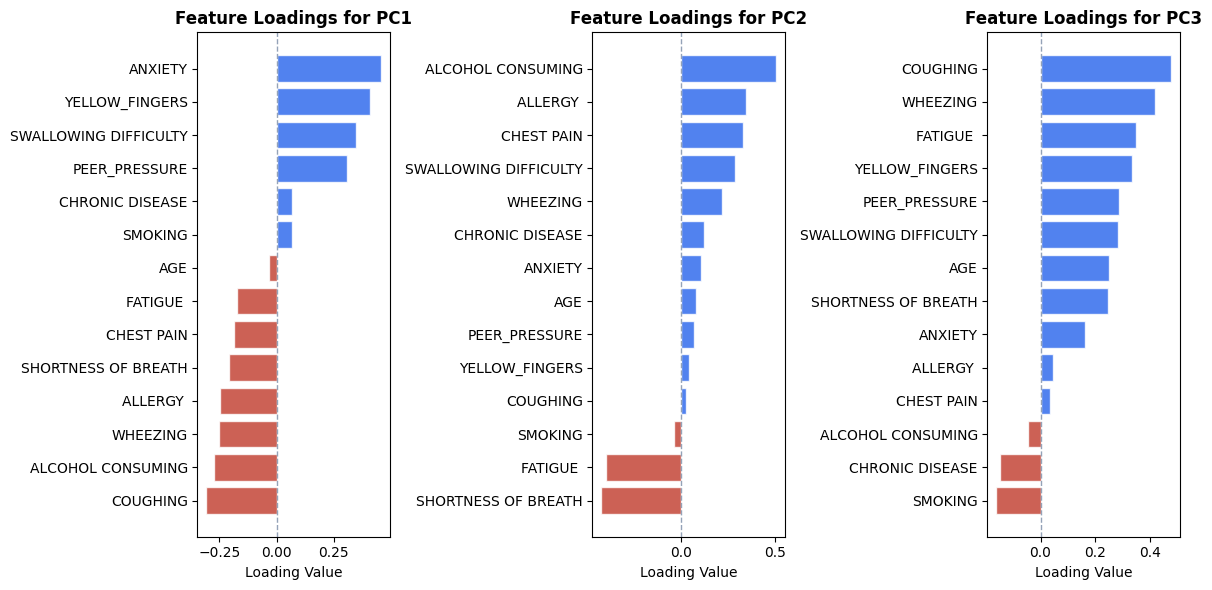

In [41]:
loadings_3d = pd.DataFrame(
    pca3d.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
).round(3)
print('PCA Loadings for 3D PCA')
print(loadings_3d.sort_values('PC1',key=abs, ascending=False))
fig, axes = plt.subplots(1,3,figsize=(12, 6))
for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    sorted_df = loadings_3d[pc].sort_values()
    colors = ['#c0392b' if val < 0 else '#2563eb' for val in sorted_df]
    ax.barh(sorted_df.index, sorted_df.values, color=colors, alpha=0.8, edgecolor='white')
    ax.set_title(f'Feature Loadings for {pc}', fontsize=12, fontweight='bold')
    ax.axvline(0, color='#94a3b8', ls='--', lw=1)
    ax.set_xlabel('Loading Value', fontsize=10)

plt.tight_layout()
plt.show()



KMeans Silhouette Score: 0.395
KMeans Davies-Bouldin Score: 1.035


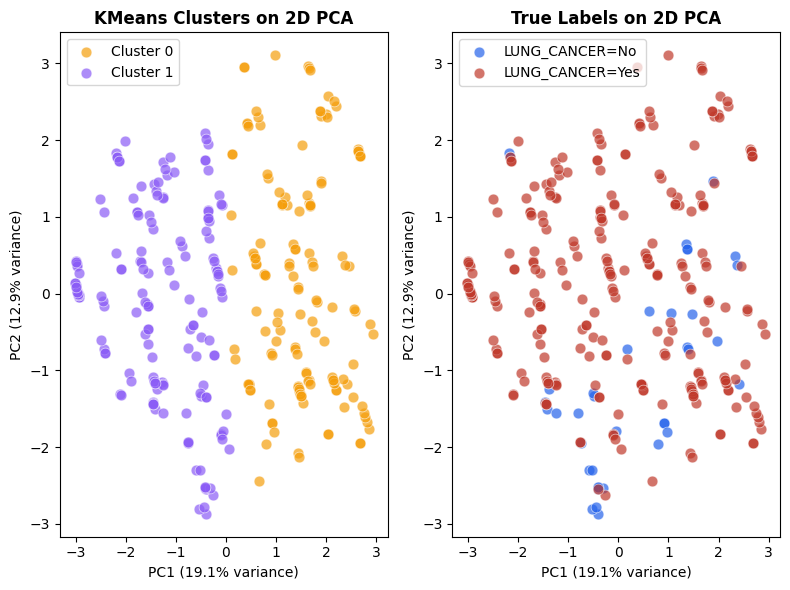

In [45]:
km = KMeans(n_clusters=2, init='k-means++', random_state=40, n_init=10)
clusters = km.fit_predict(X_pca2d)
sil = silhouette_score(X_pca2d, clusters)
dbs = davies_bouldin_score(X_pca2d, clusters)
print(f'KMeans Silhouette Score: {sil:.3f}')
print(f'KMeans Davies-Bouldin Score: {dbs:.3f}')

fig, ax = plt.subplots(1, 2,figsize=(8, 6))

colors = ['#f59e0b', '#8b5cf6']
for cls in [0,1]:
    mask = clusters == cls
    ax[0].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=f'Cluster {cls}', alpha=0.7, s=60, edgecolor='white', lw=0.5, c=colors[cls])
ax[0].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax[0].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax[0].set_title('KMeans Clusters on 2D PCA', fontsize=12, fontweight='bold')
ax[0].legend()

color_true = ['#2563eb', '#c0392b']
for cls, lbl, c in zip([0,1], ['LUNG_CANCER=No', 'LUNG_CANCER=Yes'], color_true):
    mask = y == cls
    ax[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=lbl, alpha=0.7, s=60, edgecolor='white', lw=0.5, c=c)
ax[1].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax[1].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax[1].set_title('True Labels on 2D PCA', fontsize=12, fontweight='bold')
ax[1].legend()
for ax in axes:
    ax.set_xlabel('PC1');ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()
